# Notebook 02 — Geospatial Analysis
**Project:** Natural Gas Pipeline Risk Mapping & Incident Prediction  
**Author:** Ankita Prashant Naik  

This notebook performs spatial analysis using GeoPandas: spatial joins to counties, buffer analysis around high-severity incidents, and county-level incident density choropleth maps. These spatial layers feed directly into QGIS for professional cartographic output.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120})

PROCESSED = Path('../data/processed')
RAW = Path('../data/raw')
OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

## 1. Load Clean Incidents & Convert to GeoDataFrame

In [2]:
df = pd.read_csv(PROCESSED / 'incidents_clean.csv', low_memory=False)
print(f'Loaded {len(df):,} clean incidents')

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['LOCATION_LONGITUDE'], df['LOCATION_LATITUDE']),
    crs='EPSG:4326'
)
print(f'CRS: {gdf.crs}')
gdf[['LOCATION_LATITUDE', 'LOCATION_LONGITUDE', 'high_severity', 'geometry']].head(3)

Loaded 2,675 clean incidents
CRS: EPSG:4326


,LOCATION_LATITUDE,LOCATION_LONGITUDE,high_severity,geometry
0,32.301478,-90.092257,0,POINT (-90.09226 32.30148)
1,30.666233,-90.842302,1,POINT (-90.8423 30.66623)
2,28.910845,-96.635060,1,POINT (-96.63506 28.91084)


## 2. Load US County Shapefile

In [3]:
county_shp = RAW / 'us_counties' / 'cb_2025_us_county_500k' / 'cb_2025_us_county_500k.shp'

if county_shp.exists():
    counties = gpd.read_file(county_shp).to_crs('EPSG:4326')
    # Repair invalid geometries: buffer(0) is the most reliable fix
    counties['geometry'] = counties['geometry'].buffer(0)
    counties = counties[counties.geometry.is_valid & ~counties.geometry.is_empty].copy()
    # Filter to CONUS (exclude AK, HI, territories)
    conus_fips = [str(i).zfill(2) for i in range(1, 57)
                  if i not in [2, 15, 60, 66, 69, 72, 78]]
    counties = counties[counties['STATEFP'].isin(conus_fips)]
    print(f'Loaded {len(counties):,} CONUS counties')
    counties.head(2)
else:
    print('County shapefile not found. Download from:')
    print('https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html')
    print('Save to: data/raw/us_counties/cb_2025_us_county_500k/cb_2025_us_county_500k.shp')
    counties = None

Loaded 3,109 CONUS counties


## 3. Spatial Join — Incidents to Counties
Each incident point is joined to its containing county polygon. We then aggregate by county to compute incident density.

In [4]:
if counties is not None:
    joined = gpd.sjoin(gdf, counties[['GEOID', 'NAME', 'STATEFP', 'geometry']],
                       how='left', predicate='within')
    print(f'Joined: {len(joined):,} incidents with county info')

    # County incident density
    county_counts = joined.groupby('GEOID').agg(
        incident_count=('high_severity', 'count'),
        high_severity_count=('high_severity', 'sum'),
        total_damage=('PRPTY_DAMAGE_COSTS', 'sum'),
        total_fatalities=('FATALITIES', 'sum'),
    ).reset_index()

    county_risk = counties.merge(county_counts, on='GEOID', how='left')
    county_risk['incident_count'] = county_risk['incident_count'].fillna(0)
    county_risk['high_severity_count'] = county_risk['high_severity_count'].fillna(0)
    county_risk['severity_rate'] = (
        county_risk['high_severity_count'] / county_risk['incident_count'].replace(0, np.nan)
    ).fillna(0)

    print(county_risk[['NAME', 'incident_count', 'high_severity_count', 'severity_rate']]
          .sort_values('incident_count', ascending=False).head(10))

Joined: 2,675 incidents with county info
             NAME  incident_count  high_severity_count  severity_rate
1048    Bienville            18.0                 16.0       0.888889
718    Terrebonne            18.0                 15.0       0.833333
2822         Kern            16.0                 13.0       0.812500
20         Nueces            15.0                  8.0       0.533333
1371      Cameron            15.0                 12.0       0.800000
892   Plaquemines            14.0                 12.0       0.857143
820        Harris            14.0                 10.0       0.714286
1170    Vermilion            14.0                 13.0       0.928571
867       Wharton            13.0                  8.0       0.615385
678      St. Mary            13.0                 12.0       0.923077


## 4. County Incident Density Choropleth

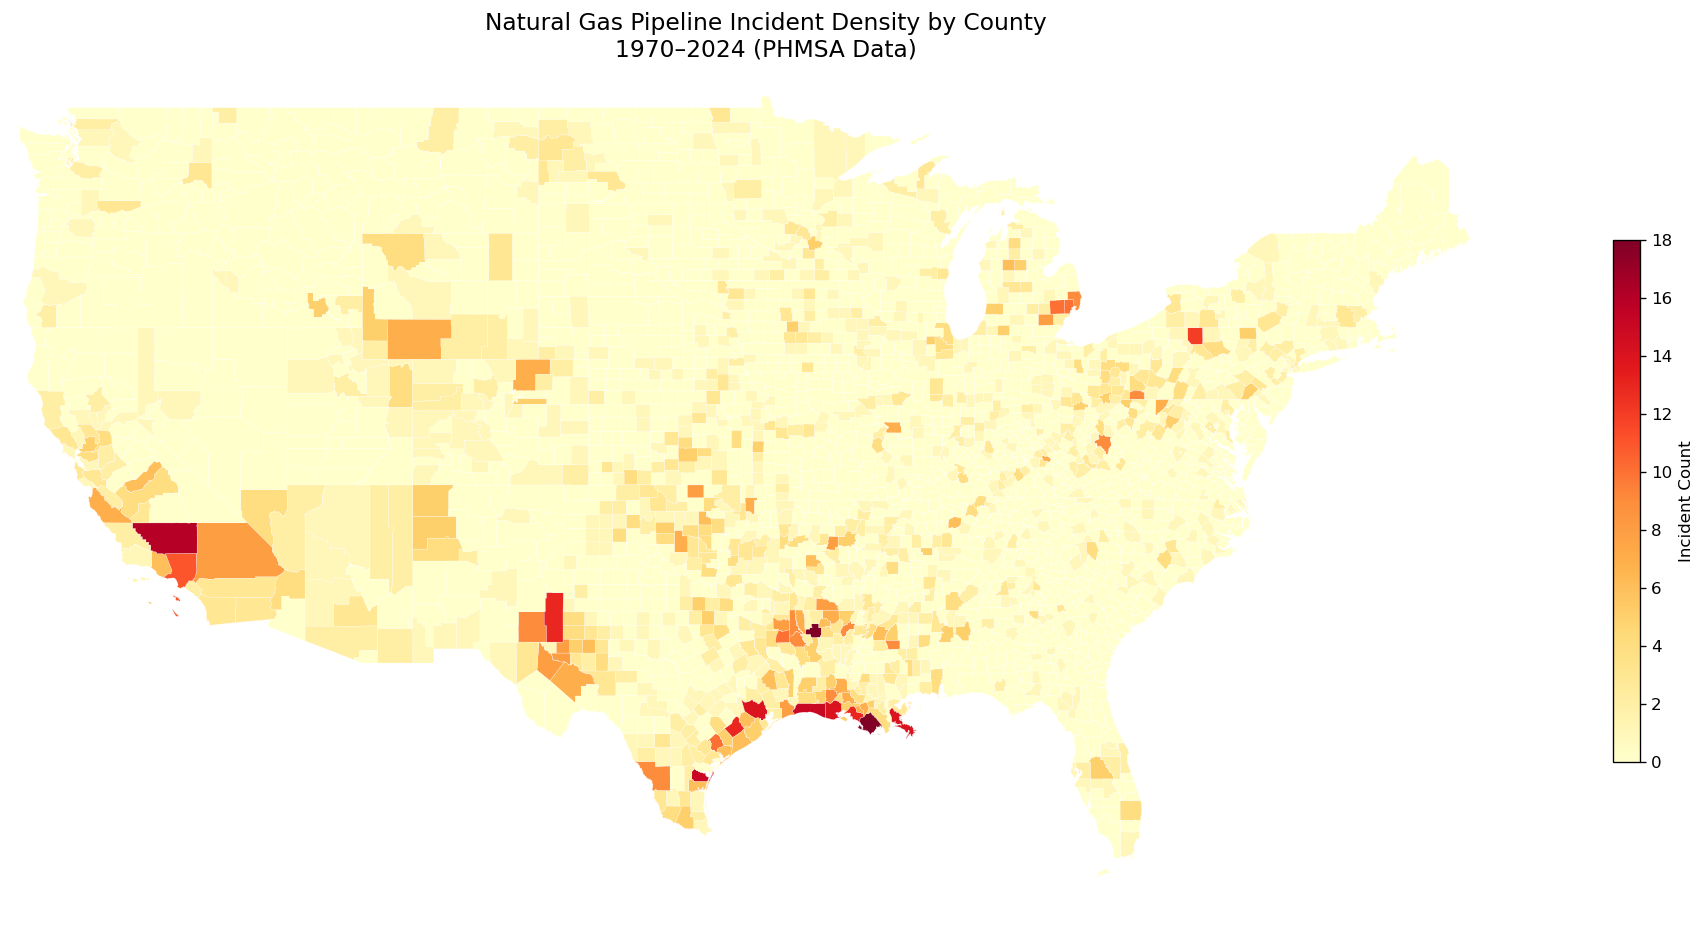

In [5]:
if counties is not None:
    fig, ax = plt.subplots(figsize=(16, 9))
    county_risk.plot(
        column='incident_count',
        cmap='YlOrRd',
        linewidth=0.15,
        edgecolor='white',
        legend=True,
        legend_kwds={'label': 'Incident Count', 'shrink': 0.5},
        ax=ax,
        missing_kwds={'color': '#F5F5F5'},
    )
    ax.set_xlim(-125, -65)
    ax.set_ylim(23, 50)
    ax.set_title('Natural Gas Pipeline Incident Density by County\n1970–2024 (PHMSA Data)',
                 fontsize=14, pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'county_choropleth.png', dpi=200, bbox_inches='tight')
    plt.show()

## 5. Buffer Analysis — Population Exposure Zones
We create 1-mile (~1.6 km) buffer zones around each high-severity incident. These buffers approximate the population zone that was exposed to the incident.

Created 2,018 buffer zones (1-mile radius) around high-severity incidents


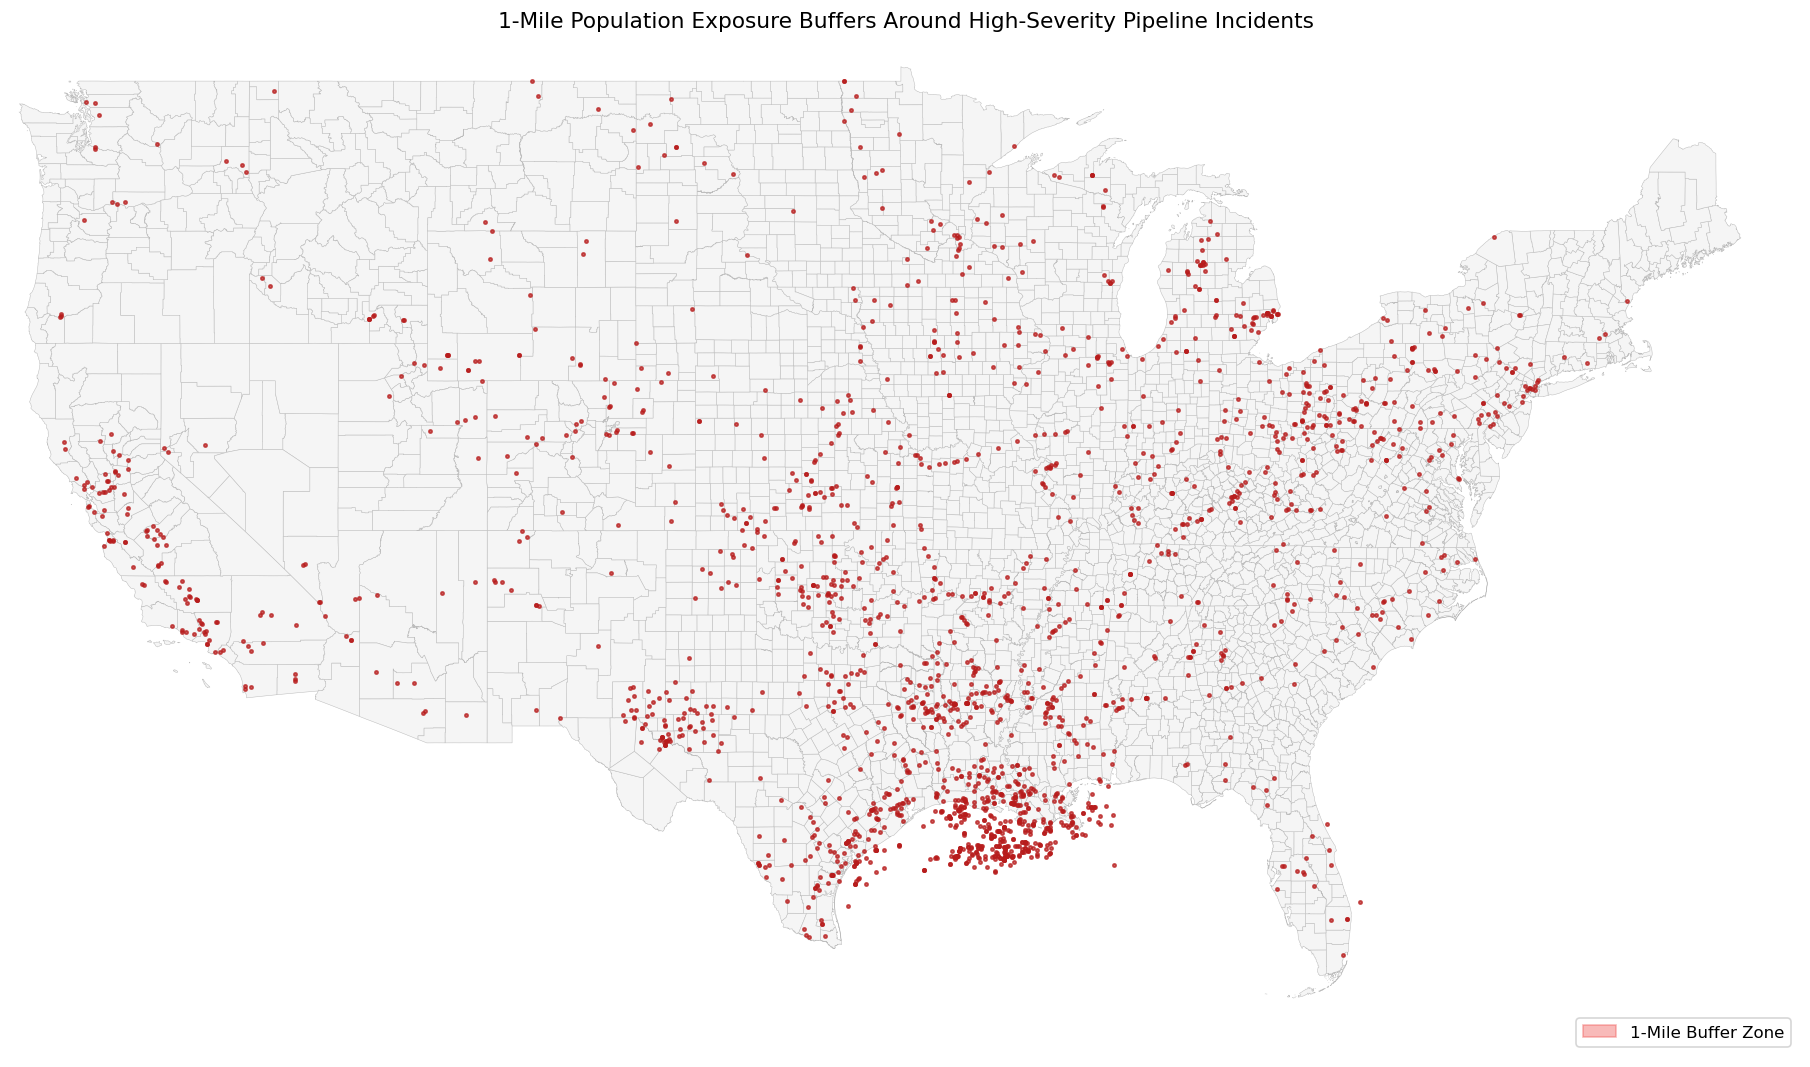

In [6]:
# Filter to CONUS bounding box — off-CONUS points produce Inf in EPSG:5070 buffers
gdf_conus = gdf[
    gdf.geometry.notna() &
    gdf.geometry.is_valid &
    gdf['LOCATION_LATITUDE'].between(23, 50) &
    gdf['LOCATION_LONGITUDE'].between(-125, -65)
].copy()

gdf_proj = gdf_conus.to_crs('EPSG:5070')  # NAD83 Conus Albers

high_sev = gdf_proj[gdf_proj['high_severity'] == 1].copy()
high_sev['buffer_1mi'] = high_sev.geometry.buffer(1609)  # 1 mile in meters
print(f'Created {len(high_sev):,} buffer zones (1-mile radius) around high-severity incidents')

# Validate buffer geometries before converting back
buffers_5070 = gpd.GeoDataFrame(high_sev, geometry='buffer_1mi', crs='EPSG:5070')
buffers_5070 = buffers_5070[buffers_5070.geometry.notna() & buffers_5070.geometry.is_valid].copy()
buffers = buffers_5070.to_crs('EPSG:4326')

if counties is not None:
    fig, ax = plt.subplots(figsize=(16, 9))
    counties.plot(ax=ax, color='#F5F5F5', edgecolor='#BDBDBD', linewidth=0.3)
    buffers.plot(ax=ax, color='#EF5350', alpha=0.25, edgecolor='none')
    gdf_conus[gdf_conus['high_severity'] == 1].plot(
        ax=ax, color='#B71C1C', markersize=4, alpha=0.7, label='High-severity incidents'
    )
    ax.set_xlim(-125, -65)
    ax.set_ylim(23, 50)
    ax.set_title('1-Mile Population Exposure Buffers Around High-Severity Pipeline Incidents',
                 fontsize=13, pad=10)
    ax.axis('off')
    red_patch = mpatches.Patch(color='#EF5350', alpha=0.4, label='1-Mile Buffer Zone')
    ax.legend(handles=[red_patch], loc='lower right')
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'population_exposure_buffers.png', dpi=200, bbox_inches='tight')
    plt.show()

## 6. Save County Risk Layer for QGIS & Modeling

In [7]:
if counties is not None:
    out_path = PROCESSED / 'county_risk.geojson'
    county_risk.to_file(out_path, driver='GeoJSON')
    print(f'County risk layer saved → {out_path}')
    print('Load this file in QGIS for choropleth mapping.')
else:
    print('Skipped — load county shapefile to generate county_risk.geojson')

County risk layer saved → ../data/processed/county_risk.geojson
Load this file in QGIS for choropleth mapping.


## 7. Top Counties by Incident Count

In [8]:
if counties is not None:
    top_counties = county_risk.nlargest(15, 'incident_count')[['NAME', 'STATEFP', 'incident_count', 'high_severity_count']]
    top_counties['severity_pct'] = (top_counties['high_severity_count'] / top_counties['incident_count'] * 100).round(1)
    print(top_counties.to_string(index=False))

       NAME STATEFP  incident_count  high_severity_count  severity_pct
 Terrebonne      22            18.0                 15.0          83.3
  Bienville      22            18.0                 16.0          88.9
       Kern      06            16.0                 13.0          81.2
     Nueces      48            15.0                  8.0          53.3
    Cameron      22            15.0                 12.0          80.0
     Harris      48            14.0                 10.0          71.4
Plaquemines      22            14.0                 12.0          85.7
  Vermilion      22            14.0                 13.0          92.9
   St. Mary      22            13.0                 12.0          92.3
    Wharton      48            13.0                  8.0          61.5
        Lea      35            13.0                  6.0          46.2
     Potter      42            12.0                  7.0          58.3
Los Angeles      06            11.0                 11.0         100.0
   Vic